In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

In [2]:
def data_raw_to_data(data_raw, data_option):
    plot_option = data_option #1 = Signal1, 2 = Signal2, 3 = delta of signals
    err = None

    #Choose what to plot
    if plot_option == 3:
        data = data_raw[1] - data_raw[2]
        shift = (data_raw.shape[0]-1)//2
        err1 = abs(data_raw[1+shift])
        err2 = abs(data_raw[2+shift])
        err = err1+err2
    else:
        data = data_raw[plot_option]
        shift = (data_raw.shape[0]-1)//2
        err = data_raw[plot_option+shift]
        
    return data, err

In [3]:
base_path = "G:\\Data\\Projects\\NbSe2\\S6\\AC studies\\"
hechos_OOC_paths_CS = glob.glob(base_path + "Set A\\300mV Lift Off\\*_Z_lift_off3.05e-07*_pulsed_measurement.dat")
hechos_OOC_paths_C0 = glob.glob(base_path + "Set A\\300mV Lift Off\\*_Z_lift_off3.05e-07*_pulsed_measurement.dat")
hechos_IC_paths_CS = glob.glob(base_path + "Set A\\300mV Lift Off\\*_Z_lift_off5e-09*_pulsed_measurement.dat")
hechos_IC_paths_C0 = glob.glob(base_path + "Set A\\300mV Lift Off\\*_Z_lift_off5e-09*_pulsed_measurement.dat")

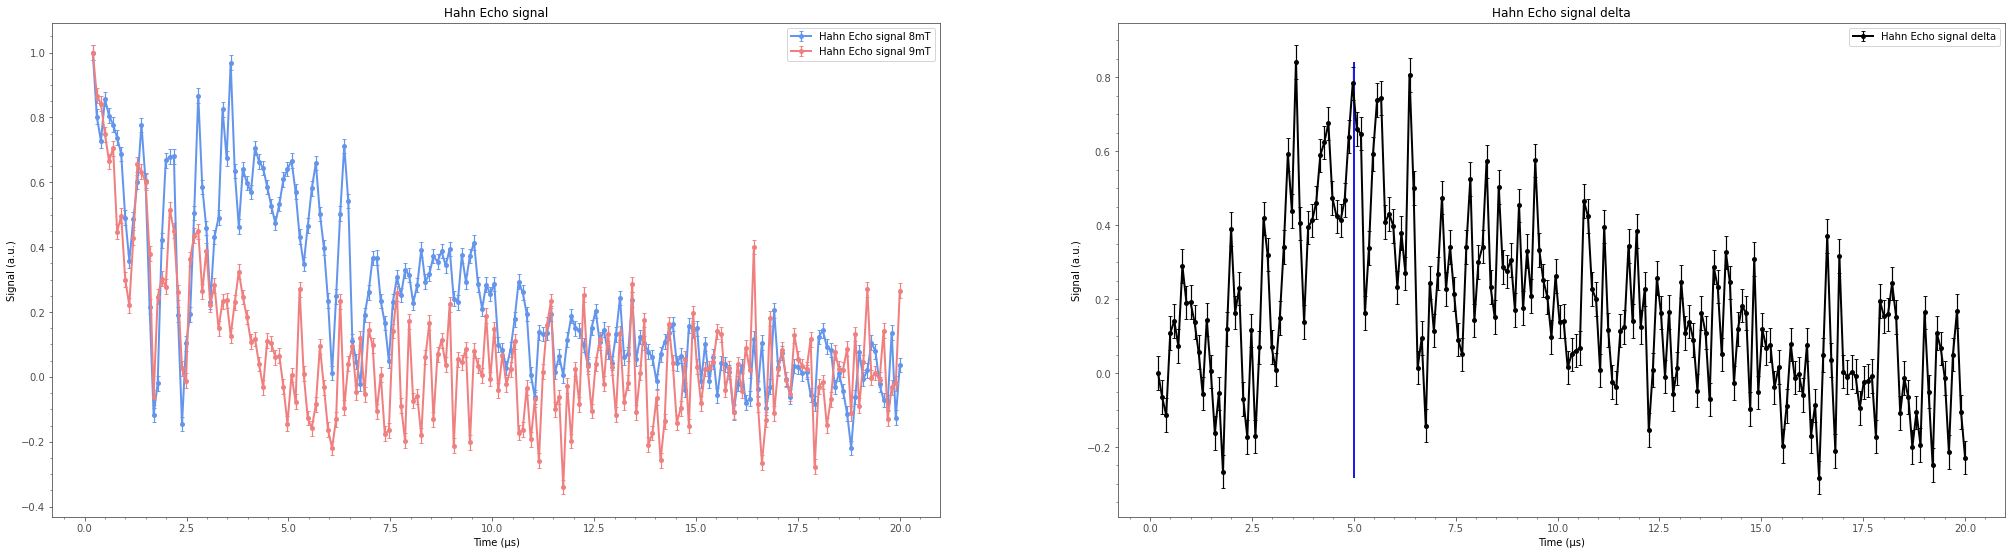

  0%|                                                                                             | 0/100 [06:55<?, ?it/s]


In [7]:
fig = plt.figure(figsize=(35,20))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
# ax1.set_xscale('log')
# ax2.set_xscale('log')

data_raw_OOC_CS = np.loadtxt(hechos_OOC_paths_CS[0]).T
#C0 is the siganl for case, where the MW is off-resonant to the NV. It is not needed for this calculation
data_raw_OOC_C0 = np.loadtxt(hechos_OOC_paths_C0[0]).T
data_raw_IC_CS = np.loadtxt(hechos_IC_paths_CS[0]).T
data_raw_IC_C0 = np.loadtxt(hechos_IC_paths_C0[0]).T

data_OOC_CS, err_OOC_CS = data_raw_to_data(data_raw_OOC_CS, 3)
data_OOC_C0, err_OOC_C0 = data_raw_to_data(data_raw_OOC_C0, 2)
data_IC_CS, err_IC_CS = data_raw_to_data(data_raw_IC_CS, 3)
data_IC_C0, err_IC_C0 = data_raw_to_data(data_raw_IC_C0, 2)

signal_OOC = data_OOC_CS/np.max(data_OOC_CS)
signal_IC = data_IC_CS/np.max(data_IC_CS)

signal_err_OOC = err_OOC_CS
signal_err_IC = err_IC_CS

# signal_err_OOC = np.sqrt((err_OOC_CS/signal_OOC[0])**2+(signal_OOC/signal_OOC[0]**2*err_OOC_CS[0])**2)

# signal_err_IC = np.sqrt((err_IC_CS/signal_IC[0])**2+(signal_IC/signal_IC[0]**2*err_IC_CS[0])**2)

signal_delta = signal_OOC-signal_IC #signal_OOC-signal_IC
signal_delta_err = signal_err_OOC+signal_err_IC

var_list = data_raw_OOC_CS[0]*1e6

ax1.errorbar(x=var_list, y=signal_OOC,
                         yerr=signal_err_OOC, fmt='-o',
                         capsize=2, capthick=0.9,
                        elinewidth=1.2, label=f'Hahn Echo signal 8mT', color='cornflowerblue')

ax1.errorbar(x=var_list, y=signal_IC,
                         yerr=signal_err_IC, fmt='-o',
                         capsize=2, capthick=0.9,
                        elinewidth=1.2, label=f'Hahn Echo signal 9mT', color='lightcoral')

ax2.errorbar(x=var_list, y=signal_delta,
                         yerr=signal_delta_err, fmt='-o',
                         capsize=2, capthick=0.9,
                        elinewidth=1.2, label=f'Hahn Echo signal delta', color='black')


ax1.title.set_text('Hahn Echo signal')
ax2.title.set_text('Hahn Echo signal delta')

ax1.set_xlabel('Time (µs)')
ax1.set_ylabel('Signal (a.u.)')
ax2.set_xlabel('Time (µs)')
ax2.set_ylabel('Signal (a.u.)')

ax1.legend()
ax2.legend()

plt.vlines(5, np.min(signal_delta), np.max(signal_delta))

plt.rcParams['figure.figsize'] = (9, 6)
fontsize = 12
plt.show()